In [89]:
# !pip install yfinance pandas ta textblob matplotlib

# Imports

In [90]:
import os
from openai import OpenAI
from dotenv import load_dotenv
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from ta.momentum import RSIIndicator
from ta.trend import SMAIndicator
from textblob import TextBlob

# Fetch Stock Data

In [91]:
def get_stock_data(ticker):
    stock = yf.Ticker(ticker)
    df = stock.history(period="5d", interval="1m")
    df = df.dropna()
    return df

# Compute Indicators

In [92]:
def compute_indicators(df):
    df['rsi'] = RSIIndicator(close=df['Close'], window=14).rsi()
    df['sma_20'] = SMAIndicator(close=df['Close'], window=20).sma_indicator()
    df['sma_50'] = SMAIndicator(close=df['Close'], window=50).sma_indicator()
    return df

# Generate Signals

In [93]:
def generate_signal(df):
    latest = df.iloc[-1]
    
    # Initialize scores
    buy_score = 0
    sell_score = 0
    hold_score = 1  # baseline so HOLD is always considered
    
    reasons = []

    # -----------------------
    # RSI Indicator
    # -----------------------
    rsi = latest['rsi']
    
    if rsi < 30:
        buy_score += 2
        reasons.append("RSI indicates oversold (buy signal)")
    elif rsi > 70:
        sell_score += 2
        reasons.append("RSI indicates overbought (sell signal)")
    else:
        hold_score += 1
        reasons.append("RSI is neutral")

    # -----------------------
    # Moving Average Trend
    # -----------------------
    sma_20 = latest['sma_20']
    sma_50 = latest['sma_50']
    
    if sma_20 > sma_50:
        buy_score += 1
        reasons.append("Short-term trend is upward (SMA20 > SMA50)")
    else:
        sell_score += 1
        reasons.append("Short-term trend is downward (SMA20 < SMA50)")

    # -----------------------
    # Optional: Volume Spike
    # -----------------------
    if 'Volume' in df.columns:
        avg_volume = df['Volume'].rolling(window=20).mean().iloc[-1]
        current_volume = latest['Volume']
        
        if current_volume > 1.5 * avg_volume:
            hold_score += 1
            reasons.append("High volume detected (possible volatility)")

    # -----------------------
    # Convert Scores → Probabilities (Softmax)
    # -----------------------
    scores = np.array([buy_score, hold_score, sell_score], dtype=float)
    
    exp_scores = np.exp(scores)
    probs = exp_scores / np.sum(exp_scores)

    buy_pct = round(probs[0] * 100, 2)
    hold_pct = round(probs[1] * 100, 2)
    sell_pct = round(probs[2] * 100, 2)

    # -----------------------
    # Final Decision
    # -----------------------
    labels = ["BUY", "HOLD", "SELL"]
    signal = labels[np.argmax(probs)]

    # -----------------------
    # Return Full Output
    # -----------------------
    return {
        "signal": signal,
        "buy_pct": buy_pct,
        "hold_pct": hold_pct,
        "sell_pct": sell_pct,
        "scores": {
            "buy": buy_score,
            "hold": hold_score,
            "sell": sell_score
        },
        "indicators": {
            "rsi": float(rsi),
            "sma_20": float(sma_20),
            "sma_50": float(sma_50)
        },
        "reasons": reasons
    }

# Sentiment Analysis

In [94]:
def analyze_sentiment(headlines):
    scores = []
    for h in headlines:
        scores.append(TextBlob(h).sentiment.polarity)
    
    avg = sum(scores) / len(scores) if scores else 0
    
    if avg > 0.1:
        return "positive"
    elif avg < -0.1:
        return "negative"
    return "neutral"

# Example headlines (replace with API later)
headlines = [
    "Apple stock rises after strong earnings",
    "Investors optimistic about new iPhone launch"
]

sentiment = analyze_sentiment(headlines)
sentiment

'positive'

# LLM Explanation 

In [95]:
def generate_explanation(ticker, signal_data, sentiment):
    explanation = f"""
Stock: {ticker}

Final Signal: {signal_data['signal']}

Probabilities:
- Buy: {signal_data['buy_pct']}%
- Hold: {signal_data['hold_pct']}%
- Sell: {signal_data['sell_pct']}%

Key Insights:
- RSI: {round(signal_data['indicators']['rsi'], 2)}
- SMA20: {round(signal_data['indicators']['sma_20'], 2)}
- SMA50: {round(signal_data['indicators']['sma_50'], 2)}
- Sentiment: {sentiment}

Reasons:
- {"; ".join(signal_data['reasons'])}



"""
    return explanation

In [ ]:
client = OpenAI(
    base_url="https://api.featherless.ai/v1",
    api_key=os.getenv("FEATHERLESS_APP_KEY"),
)

def generate_explanation_ai(ticker, signal_data, sentiment):
    prompt = f"""
You are a quantitative finance assistant.

Your job is to explain trading signals in a clear, concise, professional way.

Do NOT give financial advice. Only explain the model output.

---

STOCK DATA
Ticker: {ticker}

FINAL SIGNAL: {signal_data['signal']}

PROBABILITIES:
- Buy: {signal_data['buy_pct']}%
- Hold: {signal_data['hold_pct']}%
- Sell: {signal_data['sell_pct']}%

TECHNICAL INDICATORS:
- RSI: {round(signal_data['indicators']['rsi'], 2)}
- SMA20: {round(signal_data['indicators']['sma_20'], 2)}
- SMA50: {round(signal_data['indicators']['sma_50'], 2)}

SENTIMENT:
{sentiment}

REASONS FROM MODEL:
{", ".join(signal_data['reasons'])}

---

TASK:
Write a short explanation of why the model produced this signal.
Focus on:
- technical indicators
- sentiment influence
- overall market bias

Keep it clear and easy to understand.
"""

    response = client.chat.completions.create(
        model="meta-llama/Meta-Llama-3.1-8B-Instruct",
        messages=[
            {"role": "system", "content": "You are a helpful quantitative finance assistant."},
            {"role": "user", "content": prompt}
        ],
    )

    return response.model_dump()['choices'][0]['message']['content']

# Visualization

In [97]:
# def plot_stock(df, ticker="AAPL"):
#     plt.figure()
    
#     plt.plot(df['Close'], label="Close Price")
#     plt.plot(df['sma_20'], label="SMA 20")
#     plt.plot(df['sma_50'], label="SMA 50")
    
#     plt.title(f"{ticker} Price Chart")
#     plt.xlabel("Time")
#     plt.ylabel("Price")
#     plt.legend()
    
#     plt.show()

# Run Everything Together


Stock: AAPL

Final Signal: HOLD

Probabilities:
- Buy: 4.2%
- Hold: 84.38%
- Sell: 11.42%

Key Insights:
- RSI: 49.72
- SMA20: 248.51
- SMA50: 248.62
- Sentiment: positive

Reasons:
- RSI is neutral; Short-term trend is downward (SMA20 < SMA50); High volume detected (possible volatility)




**Model Output Explanation for AAPL**

The model has produced a HOLD signal for AAPL, indicating a neutral stance on the stock. 

**Technical Indicators:**

The Relative Strength Index (RSI) is at 49.72, which is considered neutral, neither overbought nor oversold. However, the short-term trend is downward, as indicated by the 20-day Simple Moving Average (SMA20) being lower than the 50-day Simple Moving Average (SMA50). This suggests that the stock has been trending downwards in the short term, despite a relatively flat long-term trend. Additionally, high volume has been detected, which could indicate increased volatility.

**Sentiment Influence:**

The model has detected positive sentiment surro

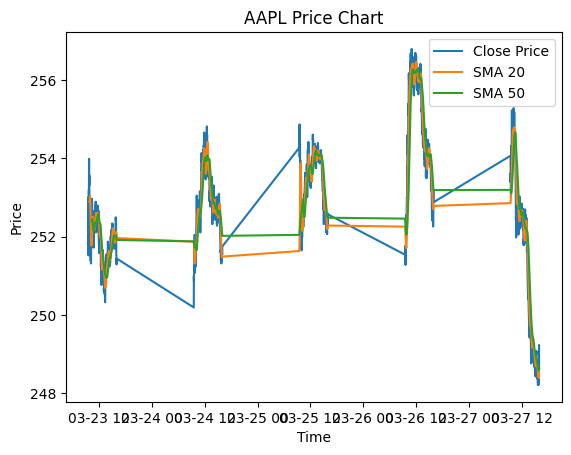

In [ ]:
def run_analysis(ticker):
    df = get_stock_data(ticker)
    df = compute_indicators(df)
    
    signal_data = generate_signal(df)
    
    headlines = [
        f"{ticker} sees strong investor interest",
        f"{ticker} market outlook remains stable"
    ]
    
    sentiment = analyze_sentiment(headlines)
    
    explanation = generate_explanation(ticker, signal_data, sentiment)
    explanation_ai = generate_explanation_ai(ticker, signal_data, sentiment)
    
    print(explanation)
    print(explanation_ai)
    # plot_stock(df, ticker)

run_analysis("AAPL")